# Genie Marketing Conversion Analysis

## Business objective

Genie Marketing is a digital marketing agency supporting a key e-commerce client whose conversion rates have been declining. The goal of this analysis is to provide a data-driven explanation of where conversion pressure may be coming from and what actions Genie should take to improve conversion performance.

This notebook reviews campaign performance, customer engagement, historical purchase behavior, creative performance, and ad spend efficiency. 

## Key business questions

1. Which factors are most associated with conversion?
2. Are declining conversions likely caused by channel mix, campaign type, creative performance, customer engagement, or spend allocation?
3. Which channels, campaign types, and creatives should Genie scale, fix, or monitor?
4. Is ad spend being used efficiently?
5. What customer engagement and historical purchase signals should be used for targeting?
6. What data is missing to fully diagnose the decline over time?
7. Which metrics should management track after implementing the recommendations?

In [1]:
from pathlib import Path
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

warnings.filterwarnings("ignore")

BASE_DIR = Path.cwd()
DATA_FILE = BASE_DIR / "digital_marketing_campaign_dataset_with_creative.csv"

pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

def pct(value, decimals=1):
    return f"{value * 100:.{decimals}f}%"

def money(value, decimals=0):
    return f"${value:,.{decimals}f}"

Could not save font_manager cache [Errno 13] Permission denied: 'C:\\Users\\Estefania\\.matplotlib\\fontlist-v390.json.matplotlib-lock'


## 1. Load the dataset

**Fact:** The dataset contains marketing campaign, engagement, historical purchase, and conversion fields.

**Assumption:** Each row is treated as one customer-campaign interaction. `Conversion` is the binary target variable, while `ConversionRate` is treated as a campaign-level input metric.

In [2]:
df = pd.read_csv(DATA_FILE)

creative_parts = df["CreativeName"].str.split("_", expand=True)
df[["Geo", "Device", "OS", "Theme", "Size"]] = creative_parts.iloc[:, :5]

print(f"Rows: {len(df):,}")
print(f"Columns: {df.shape[1]:,}")
print(f"Conversions: {df['Conversion'].sum():,}")
print(f"Overall conversion rate: {pct(df['Conversion'].mean(), 2)}")
df.head()

Rows: 8,000
Columns: 22
Conversions: 7,012
Overall conversion rate: 87.65%


,CreativeName,CampaignChannel,CampaignType,AdSpend,ClickThroughRate,ConversionRate,WebsiteVisits,PagesPerVisit,TimeOnSite,SocialShares,EmailOpens,EmailClicks,PreviousPurchases,LoyaltyPoints,AdvertisingPlatform,AdvertisingTool,Conversion,Geo,Device,OS,Theme,Size
0,CA_Desktop_Windows_Soccer_300x600,Social Media,Awareness,"6,497.8701",0.0439,0.0880,0,2.3990,7.3968,19,6,9,4,688,IsConfid,ToolConfid,1,CA,Desktop,Windows,Soccer,300x600
1,US_Mobile_iOS_NBA_320x50,Programmatic Ads,Retention,"3,898.6686",0.1557,0.1827,42,2.9171,5.3525,5,2,7,2,3459,IsConfid,ToolConfid,1,US,Mobile,iOS,NBA,320x50
2,US_Mobile_Android_NBA_300x600,Programmatic Ads,Awareness,"1,546.4296",0.2775,0.0764,2,8.2236,13.7949,0,11,2,8,2337,IsConfid,ToolConfid,1,US,Mobile,Android,NBA,300x600
3,CA_Mobile_iOS_Soccer_728x90,Programmatic Ads,Conversion,539.5259,0.1376,0.0880,47,4.5409,14.6884,89,2,2,0,2463,IsConfid,ToolConfid,1,CA,Mobile,iOS,Soccer,728x90
4,BR_Desktop_Windows_Soccer_300x600,Programmatic Ads,Conversion,"1,678.0436",0.2529,0.1099,0,2.0468,13.9934,6,6,6,8,4345,IsConfid,ToolConfid,1,BR,Desktop,Windows,Soccer,300x600


## 2. Data quality review

**Fact:** The source file has no missing values in the provided columns.

**Business meaning:** The dataset is complete enough for segmentation and driver analysis. However, completeness does not mean the file is sufficient for trend diagnosis because it does not include a date field.

In [3]:
missing = df.isna().sum().rename("MissingValues").reset_index().rename(columns={"index": "Column"})
dtypes = df.dtypes.astype(str).rename("DataType").reset_index().rename(columns={"index": "Column"})
quality = missing.merge(dtypes, on="Column")
quality

,Column,MissingValues,DataType
0,CreativeName,0,object
1,CampaignChannel,0,object
2,CampaignType,0,object
3,AdSpend,0,float64
4,ClickThroughRate,0,float64
5,ConversionRate,0,float64
6,WebsiteVisits,0,int64
7,PagesPerVisit,0,float64
8,TimeOnSite,0,float64
9,SocialShares,0,int64


In [4]:
numeric_columns = [
    "AdSpend", "ClickThroughRate", "ConversionRate", "WebsiteVisits",
    "PagesPerVisit", "TimeOnSite", "SocialShares", "EmailOpens",
    "EmailClicks", "PreviousPurchases", "LoyaltyPoints"
]

df[numeric_columns].describe(percentiles=[0.05, 0.25, 0.50, 0.75, 0.95]).T

,count,mean,std,min,5%,25%,50%,75%,95%,max
AdSpend,"8,000.0000","5,000.9448","2,838.0382",100.0548,613.5448,"2,523.2212","5,013.4400","7,407.9894","9,470.4932","9,997.9148"
ClickThroughRate,"8,000.0000",0.1548,0.0840,0.0100,0.0245,0.0826,0.1545,0.2282,0.2857,0.3000
ConversionRate,"8,000.0000",0.1044,0.0549,0.0100,0.0192,0.0564,0.1040,0.1521,0.1899,0.2000
WebsiteVisits,"8,000.0000",24.7516,14.3123,0.0000,2.0000,13.0000,25.0000,37.0000,47.0000,49.0000
PagesPerVisit,"8,000.0000",5.5493,2.6074,1.0004,1.4823,3.3025,5.5343,7.8358,9.5812,9.9991
TimeOnSite,"8,000.0000",7.7277,4.2282,0.5017,1.1648,4.0683,7.6830,11.4815,14.3071,14.9953
SocialShares,"8,000.0000",49.7998,28.9012,0.0000,4.0000,25.0000,50.0000,75.0000,95.0000,99.0000
EmailOpens,"8,000.0000",9.4769,5.7111,0.0000,0.0000,5.0000,9.0000,14.0000,18.0000,19.0000
EmailClicks,"8,000.0000",4.4674,2.8566,0.0000,0.0000,2.0000,4.0000,7.0000,9.0000,9.0000
PreviousPurchases,"8,000.0000",4.4855,2.8881,0.0000,0.0000,2.0000,4.0000,7.0000,9.0000,9.0000


## 3. Conversion baseline

**Fact:** The dataset conversion rate is high overall. This means the analysis should focus on relative differences between segments rather than interpreting the absolute rate in isolation.

**Important limitation:** There is no date field, so this notebook cannot directly prove month-over-month decline. It identifies likely current drivers and optimization opportunities.

In [5]:
conversion_counts = df["Conversion"].value_counts().rename_axis("Conversion").reset_index(name="Records")
conversion_counts["Share"] = conversion_counts["Records"] / conversion_counts["Records"].sum()
conversion_counts

,Conversion,Records,Share
0,1,7012,0.8765
1,0,988,0.1235


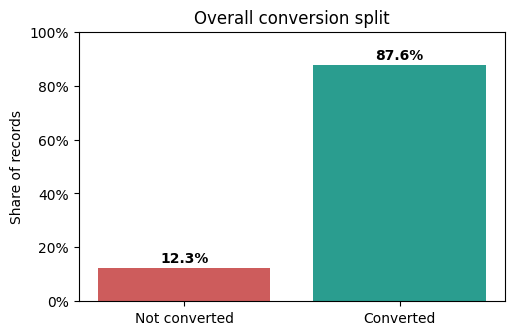

In [6]:
fig, ax = plt.subplots(figsize=(5.5, 3.5))
labels = ["Not converted", "Converted"]
values = [
    (df["Conversion"] == 0).mean(),
    (df["Conversion"] == 1).mean()
]
ax.bar(labels, values, color=["#CD5C5C", "#2A9D8F"])
ax.set_ylim(0, 1)
ax.set_ylabel("Share of records")
ax.set_title("Overall conversion split")
ax.yaxis.set_major_formatter(lambda v, pos: f"{v*100:.0f}%")
for i, v in enumerate(values):
    ax.text(i, v + 0.02, pct(v, 1), ha="center", fontweight="bold")
plt.show()

## 4. Main conversion drivers

This section compares converted and non-converted records and also measures high-vs-low quartile lift for each numeric variable.

**Business meaning:** A variable is more actionable when high values are associated with meaningfully higher conversion and the variable can be influenced through targeting, creative, email, landing pages, or customer strategy.

In [7]:
converted_vs_not = []
for col in numeric_columns:
    means = df.groupby("Conversion")[col].mean()
    medians = df.groupby("Conversion")[col].median()
    converted_vs_not.append({
        "Metric": col,
        "NonConvertedMean": means.get(0, np.nan),
        "ConvertedMean": means.get(1, np.nan),
        "Difference": means.get(1, np.nan) - means.get(0, np.nan),
        "RelativeDifference": (means.get(1, np.nan) - means.get(0, np.nan)) / means.get(0, np.nan),
        "NonConvertedMedian": medians.get(0, np.nan),
        "ConvertedMedian": medians.get(1, np.nan),
        "CorrelationWithConversion": df[col].corr(df["Conversion"])
    })

converted_vs_not = pd.DataFrame(converted_vs_not).sort_values("CorrelationWithConversion", ascending=False)
converted_vs_not

,Metric,NonConvertedMean,ConvertedMean,Difference,RelativeDifference,NonConvertedMedian,ConvertedMedian,CorrelationWithConversion
5,TimeOnSite,6.2679,7.9334,1.6655,0.2657,4.9668,7.9217,0.1296
8,EmailClicks,3.4818,4.6062,1.1245,0.3230,3.0000,5.0000,0.1295
7,EmailOpens,7.5769,9.7446,2.1677,0.2861,6.0000,10.0000,0.1249
0,AdSpend,"4,058.3985","5,133.7508","1,075.3524",0.2650,"3,554.5550","5,249.7187",0.1247
1,ClickThroughRate,0.1280,0.1586,0.0306,0.2394,0.1034,0.1592,0.1200
9,PreviousPurchases,3.6255,4.6067,0.9812,0.2706,3.0000,5.0000,0.1118
4,PagesPerVisit,4.8350,5.6499,0.8149,0.1686,4.3719,5.6734,0.1028
10,LoyaltyPoints,"2,128.4838","2,541.2444",412.7606,0.1939,"1,968.5000","2,552.5000",0.0950
2,ConversionRate,0.0908,0.1063,0.0155,0.1712,0.0815,0.1065,0.0932
3,WebsiteVisits,21.7267,25.1778,3.4511,0.1588,20.0000,25.0000,0.0793


In [8]:
quartile_lift = []
for col in numeric_columns:
    low = df[col] <= df[col].quantile(0.25)
    high = df[col] >= df[col].quantile(0.75)
    quartile_lift.append({
        "Metric": col,
        "LowQuartileConversionRate": df.loc[low, "Conversion"].mean(),
        "HighQuartileConversionRate": df.loc[high, "Conversion"].mean(),
        "LiftPP": df.loc[high, "Conversion"].mean() - df.loc[low, "Conversion"].mean(),
        "LowQuartileAverage": df.loc[low, col].mean(),
        "HighQuartileAverage": df.loc[high, col].mean(),
    })

quartile_lift = pd.DataFrame(quartile_lift).sort_values("LiftPP", ascending=False)
quartile_lift

,Metric,LowQuartileConversionRate,HighQuartileConversionRate,LiftPP,LowQuartileAverage,HighQuartileAverage
8,EmailClicks,0.8022,0.9168,0.1146,1.0112,7.9932
5,TimeOnSite,0.8015,0.9145,0.1130,2.2532,13.2556
7,EmailOpens,0.8041,0.9120,0.1079,2.5125,16.4979
1,ClickThroughRate,0.8035,0.9090,0.1055,0.0462,0.2644
4,PagesPerVisit,0.7940,0.8970,0.1030,2.1642,8.9166
0,AdSpend,0.8280,0.9240,0.0960,"1,332.3647","8,700.4547"
2,ConversionRate,0.8045,0.8990,0.0945,0.0335,0.1758
9,PreviousPurchases,0.8100,0.9033,0.0933,0.9730,8.0231
10,LoyaltyPoints,0.8150,0.9035,0.0885,639.3640,"4,356.3095"
3,WebsiteVisits,0.8190,0.8890,0.0701,6.5299,42.9981


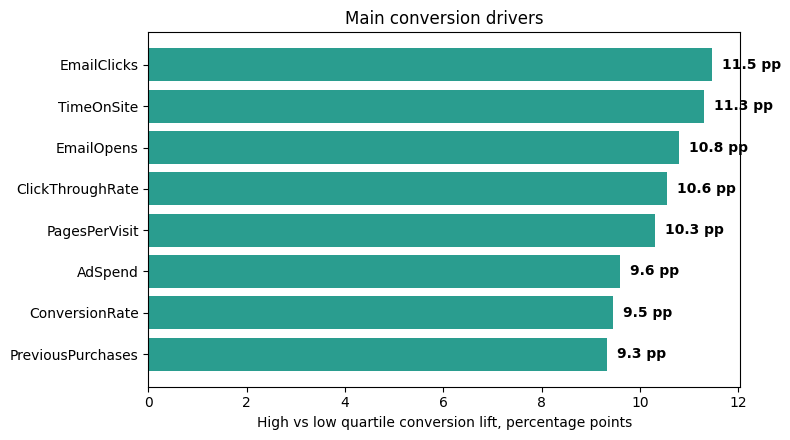

In [9]:
top_lift = quartile_lift.head(8).sort_values("LiftPP")

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.barh(top_lift["Metric"], top_lift["LiftPP"] * 100, color="#2A9D8F")
ax.set_xlabel("High vs low quartile conversion lift, percentage points")
ax.set_title("Main conversion drivers")
for i, v in enumerate(top_lift["LiftPP"] * 100):
    ax.text(v + 0.2, i, f"{v:.1f} pp", va="center", fontweight="bold")
plt.tight_layout()
plt.show()

### Driver interpretation and recommended action

**Facts**
- High `EmailClicks`, `TimeOnSite`, `EmailOpens`, `ClickThroughRate`, and `PagesPerVisit` show the strongest conversion lift.
- Converted customers also have higher prior purchase and loyalty behavior than non-converted customers.

**Business meaning**
- Conversions are strongly connected to intent and relationship depth.
- Genie should not only optimize for clicks. It should optimize for qualified clicks and post-click engagement.

**Recommended action**
- Build priority audiences from email clickers, high time-on-site visitors, previous buyers, and loyalty members.
- Route lower-engagement visitors to nurture or retargeting journeys before pushing direct conversion offers.

## 5. Channel and campaign type performance

The agency needs to know whether the issue is caused by broad channel mix or by more specific execution choices inside each channel.

In [10]:
def performance_table(group_cols):
    table = (
        df.groupby(group_cols)
        .agg(
            Records=("Conversion", "size"),
            ConversionRate=("Conversion", "mean"),
            AvgCTR=("ClickThroughRate", "mean"),
            AvgCampaignConversionRate=("ConversionRate", "mean"),
            TotalSpend=("AdSpend", "sum"),
            Conversions=("Conversion", "sum"),
        )
        .reset_index()
    )
    table["SpendPerConversion"] = table["TotalSpend"] / table["Conversions"].replace(0, np.nan)
    return table.sort_values("ConversionRate", ascending=False)

channel_perf = performance_table("CampaignChannel")
type_perf = performance_table("CampaignType")
channel_type_perf = performance_table(["CampaignChannel", "CampaignType"])

channel_perf

,CampaignChannel,Records,ConversionRate,AvgCTR,AvgCampaignConversionRate,TotalSpend,Conversions,SpendPerConversion
0,Programmatic Ads,4762,0.8767,0.1557,0.1042,"23,811,716.7087",4175,"5,703.4052"
1,Social Media,3238,0.8762,0.1535,0.1047,"16,195,841.9347",2837,"5,708.7917"


In [11]:
type_perf

,CampaignType,Records,ConversionRate,AvgCTR,AvgCampaignConversionRate,TotalSpend,Conversions,SpendPerConversion
2,Conversion,2077,0.9336,0.1557,0.1049,"10,300,076.9813",1939,"5,312.0562"
3,Retention,1947,0.8582,0.1561,0.1032,"9,768,362.1611",1671,"5,845.8182"
1,Consideration,1988,0.8556,0.1518,0.1051,"9,861,273.6746",1701,"5,797.3390"
0,Awareness,1988,0.8556,0.1558,0.1044,"10,077,845.8264",1701,"5,924.6595"


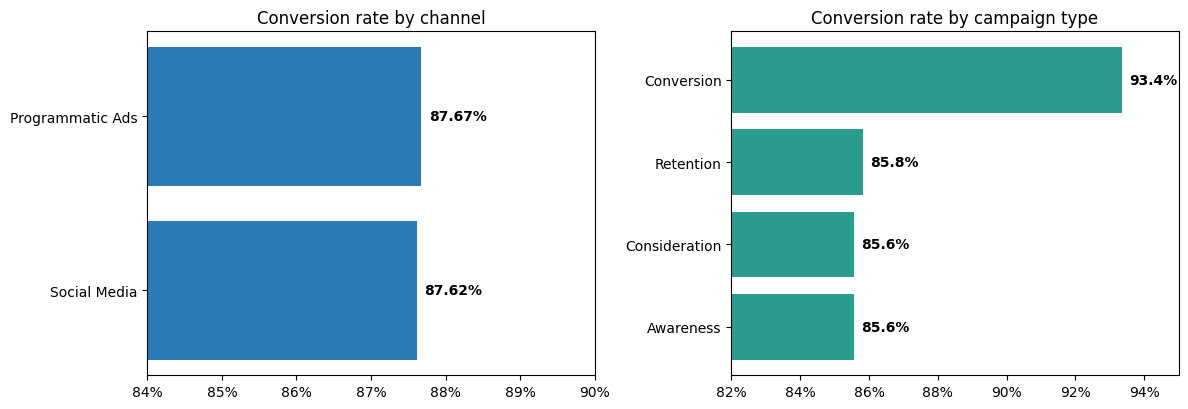

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))

channel_plot = channel_perf.sort_values("ConversionRate")
axes[0].barh(channel_plot["CampaignChannel"], channel_plot["ConversionRate"], color="#2C7BB6")
axes[0].set_title("Conversion rate by channel")
axes[0].set_xlim(0.84, 0.90)
axes[0].xaxis.set_major_formatter(lambda v, pos: f"{v*100:.0f}%")
for i, v in enumerate(channel_plot["ConversionRate"]):
    axes[0].text(v + 0.001, i, pct(v, 2), va="center", fontweight="bold")

type_plot = type_perf.sort_values("ConversionRate")
axes[1].barh(type_plot["CampaignType"], type_plot["ConversionRate"], color="#2A9D8F")
axes[1].set_title("Conversion rate by campaign type")
axes[1].set_xlim(0.82, 0.95)
axes[1].xaxis.set_major_formatter(lambda v, pos: f"{v*100:.0f}%")
for i, v in enumerate(type_plot["ConversionRate"]):
    axes[1].text(v + 0.002, i, pct(v, 1), va="center", fontweight="bold")

plt.tight_layout()
plt.show()

### Channel and campaign interpretation

**Facts**
- Programmatic Ads and Social Media have nearly identical conversion rates.
- Conversion campaigns materially outperform Awareness, Consideration, and Retention campaigns.

**Business meaning**
- A broad channel shift is unlikely to solve the conversion decline.
- Campaign objective is a clearer lever than channel.

**Recommended action**
- Keep both channels active.
- Reallocate inside each channel toward stronger campaign types and high-intent audiences.
- Measure upper-funnel campaigns with assisted and engagement KPIs, not only final conversion.

## 6. Creative performance

Creative performance is analyzed at two levels:

1. Direct creative name performance.
2. Parsed creative dimensions from `CreativeName`: geography, device, OS, theme, and size.

In [13]:
creative_perf = (
    df.groupby("CreativeName")
    .agg(
        Records=("Conversion", "size"),
        ConversionRate=("Conversion", "mean"),
        AvgCTR=("ClickThroughRate", "mean"),
        TotalSpend=("AdSpend", "sum"),
        Conversions=("Conversion", "sum"),
        AvgTimeOnSite=("TimeOnSite", "mean"),
    )
    .reset_index()
)
creative_perf["SpendPerConversion"] = creative_perf["TotalSpend"] / creative_perf["Conversions"].replace(0, np.nan)

top_creatives = creative_perf[creative_perf["Records"] >= 40].sort_values(
    ["ConversionRate", "Conversions"], ascending=False
).head(10)

bottom_creatives = creative_perf[creative_perf["Records"] >= 40].sort_values(
    ["ConversionRate", "Conversions"], ascending=True
).head(10)

top_creatives

,CreativeName,Records,ConversionRate,AvgCTR,TotalSpend,Conversions,AvgTimeOnSite,SpendPerConversion
188,US_Mobile_Android_NBA_320x50,51,0.9804,0.1611,"252,964.6567",50,8.7037,"5,059.2931"
49,CA_Desktop_OS X_NFL_300x600,41,0.9756,0.1693,"187,909.9690",40,8.0980,"4,697.7492"
60,CA_Desktop_Windows_NBA_300x250,57,0.9649,0.1798,"283,423.1190",55,8.4390,"5,153.1476"
194,US_Mobile_Android_PGA_300x250,53,0.9623,0.1613,"240,928.5408",51,7.8956,"4,724.0890"
182,US_Desktop_Windows_Soccer_300x250,73,0.9589,0.1697,"397,346.1908",70,7.3742,"5,676.3742"
171,US_Desktop_Windows_NBA_300x600,71,0.9577,0.1669,"333,873.9909",68,8.1287,"4,909.9116"
184,US_Desktop_Windows_Soccer_320x50,64,0.9531,0.1581,"272,819.3884",61,8.0451,"4,472.4490"
94,CA_Mobile_iOS_NFL_320x50,70,0.9429,0.1394,"399,198.2535",66,6.8518,"6,048.4584"
68,CA_Desktop_Windows_PGA_300x250,45,0.9333,0.1648,"224,524.3070",42,8.6423,"5,345.8168"
92,CA_Mobile_iOS_NFL_300x250,40,0.9250,0.1563,"213,722.9244",37,6.7530,"5,776.2953"


In [14]:
bottom_creatives

,CreativeName,Records,ConversionRate,AvgCTR,TotalSpend,Conversions,AvgTimeOnSite,SpendPerConversion
83,CA_Mobile_Android_NFL_728x90,77,0.7532,0.1498,"390,177.5802",58,7.0658,"6,727.1997"
82,CA_Mobile_Android_NFL_320x50,98,0.7653,0.1491,"522,968.2552",75,7.6257,"6,972.9101"
192,US_Mobile_Android_NFL_320x50,143,0.7832,0.1496,"688,927.2993",112,7.6665,"6,151.1366"
80,CA_Mobile_Android_NFL_300x250,117,0.7863,0.1481,"608,973.7091",92,7.2648,"6,619.2794"
51,CA_Desktop_OS X_NFL_728x90,57,0.7895,0.1436,"296,657.7458",45,7.6093,"6,592.3944"
15,BR_Desktop_Windows_NFL_300x250,48,0.7917,0.1643,"226,001.8085",38,7.1620,"5,947.4160"
121,MX_Desktop_Windows_NFL_300x250,53,0.7925,0.1489,"233,600.8382",42,7.2242,"5,561.9247"
66,CA_Desktop_Windows_NFL_320x50,147,0.7959,0.1663,"726,752.8306",117,7.4978,"6,211.5627"
191,US_Mobile_Android_NFL_300x600,97,0.8041,0.1516,"500,331.7396",78,8.3968,"6,414.5095"
140,MX_Mobile_Android_NFL_728x90,41,0.8049,0.1471,"217,509.0795",33,6.4831,"6,591.1842"


In [15]:
theme_perf = performance_table("Theme")
device_perf = performance_table("Device")
os_perf = performance_table("OS")
size_perf = performance_table("Size")

display(theme_perf)
display(device_perf)
display(os_perf)
display(size_perf)

,Theme,Records,ConversionRate,AvgCTR,AvgCampaignConversionRate,TotalSpend,Conversions,SpendPerConversion
3,Soccer,684,0.9225,0.1553,0.1069,"3,357,886.0439",631,"5,321.5310"
0,NBA,1674,0.8973,0.1586,0.1045,"8,348,275.7075",1502,"5,558.1063"
2,PGA,1224,0.8922,0.1538,0.1036,"6,098,865.0215",1092,"5,585.0412"
1,NFL,4418,0.8572,0.1536,0.1042,"22,202,531.8705",3787,"5,862.8286"


,Device,Records,ConversionRate,AvgCTR,AvgCampaignConversionRate,TotalSpend,Conversions,SpendPerConversion
0,Desktop,5303,0.8829,0.1562,0.1039,"26,505,752.7345",4682,"5,661.2031"
1,Mobile,2697,0.8639,0.1521,0.1054,"13,501,805.9089",2330,"5,794.7665"


,OS,Records,ConversionRate,AvgCTR,AvgCampaignConversionRate,TotalSpend,Conversions,SpendPerConversion
3,iOS,865,0.9040,0.1482,0.1058,"4,360,563.0120",782,"5,576.1675"
2,Windows,3379,0.8831,0.1562,0.1044,"16,699,430.6728",2984,"5,596.3240"
1,OS X,1924,0.8825,0.1562,0.1029,"9,806,322.0617",1698,"5,775.2191"
0,Android,1832,0.8450,0.1540,0.1052,"9,141,242.8969",1548,"5,905.1957"


,Size,Records,ConversionRate,AvgCTR,AvgCampaignConversionRate,TotalSpend,Conversions,SpendPerConversion
1,300x600,1516,0.8806,0.1529,0.1049,"7,481,786.7433",1335,"5,604.3346"
0,300x250,2512,0.8786,0.1573,0.1033,"12,519,575.8020",2207,"5,672.6669"
3,728x90,1768,0.8739,0.1530,0.1048,"8,935,728.5236",1545,"5,783.6431"
2,320x50,2204,0.8734,0.1548,0.1049,"11,070,467.5745",1925,"5,750.8922"


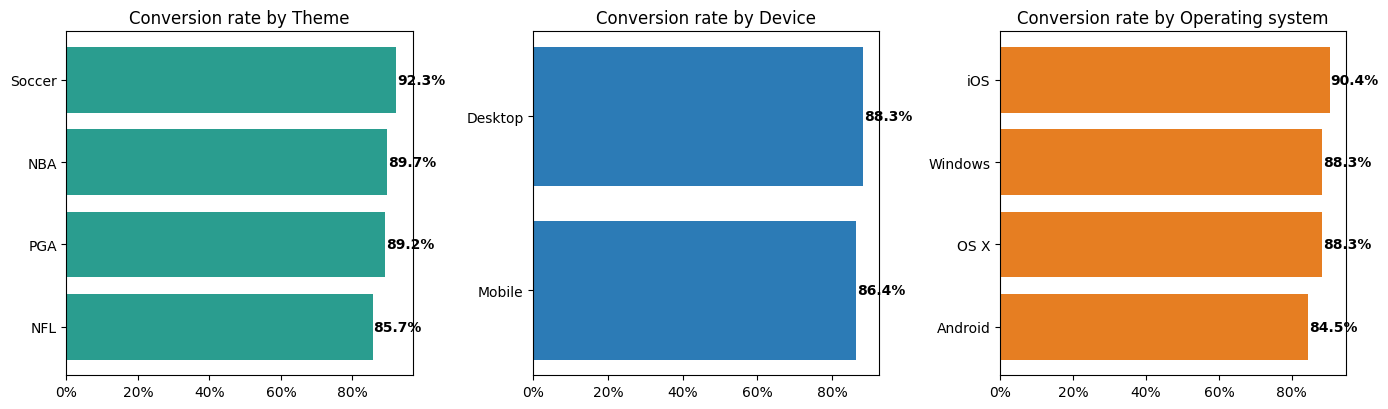

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4.2))

for ax, table, col, title, color in [
    (axes[0], theme_perf.sort_values("ConversionRate"), "Theme", "Theme", "#2A9D8F"),
    (axes[1], device_perf.sort_values("ConversionRate"), "Device", "Device", "#2C7BB6"),
    (axes[2], os_perf.sort_values("ConversionRate"), "OS", "Operating system", "#E67E22"),
]:
    ax.barh(table[col], table["ConversionRate"], color=color)
    ax.set_title(f"Conversion rate by {title}")
    ax.xaxis.set_major_formatter(lambda v, pos: f"{v*100:.0f}%")
    for i, v in enumerate(table["ConversionRate"]):
        ax.text(v + 0.002, i, pct(v, 1), va="center", fontweight="bold")

plt.tight_layout()
plt.show()

### Creative interpretation and recommended action

**Facts**
- Soccer creatives outperform NFL creatives.
- Desktop outperforms Mobile.
- iOS outperforms Android.
- Several lower-performing creatives are concentrated in Mobile Android NFL combinations.

**Business meaning**
- Creative performance depends on audience context, device, and format.
- NFL creative volume may be dragging total conversion if it continues receiving heavy spend without refresh.

**Recommended action**
- Refresh or pause weak Mobile Android NFL creatives.
- Test new landing pages or messaging for Android users.
- Scale winning creative patterns while reserving budget for controlled creative testing.

## 7. Ad spend efficiency

This section evaluates whether higher ad spend is producing better conversion performance and whether the cost per conversion remains efficient.

In [17]:
df["SpendQuartile"] = pd.qcut(df["AdSpend"], 4, labels=["Q1 lowest", "Q2", "Q3", "Q4 highest"])

spend_perf = (
    df.groupby("SpendQuartile", observed=True)
    .agg(
        Records=("Conversion", "size"),
        AvgSpend=("AdSpend", "mean"),
        TotalSpend=("AdSpend", "sum"),
        ConversionRate=("Conversion", "mean"),
        Conversions=("Conversion", "sum"),
        AvgCTR=("ClickThroughRate", "mean"),
        AvgCampaignConversionRate=("ConversionRate", "mean"),
    )
    .reset_index()
)
spend_perf["SpendPerConversion"] = spend_perf["TotalSpend"] / spend_perf["Conversions"]
spend_perf

,SpendQuartile,Records,AvgSpend,TotalSpend,ConversionRate,Conversions,AvgCTR,AvgCampaignConversionRate,SpendPerConversion
0,Q1 lowest,2000,"1,332.3647","2,664,729.4383",0.8280,1656,0.1572,0.1037,"1,609.1361"
1,Q2,2000,"3,745.1708","7,490,341.5555",0.8325,1665,0.1531,0.1080,"4,498.7036"
2,Q3,2000,"6,225.7891","12,451,578.2279",0.9215,1843,0.1555,0.1034,"6,756.1466"
3,Q4 highest,2000,"8,700.4547","17,400,909.4216",0.9240,1848,0.1535,0.1025,"9,416.0765"


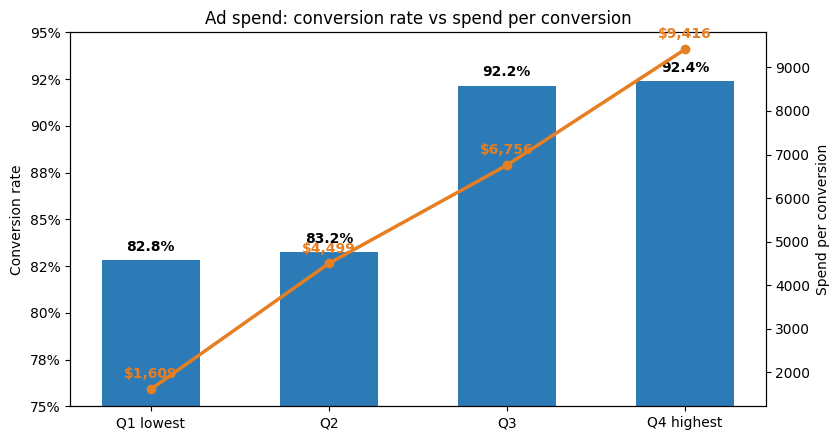

In [18]:
fig, ax1 = plt.subplots(figsize=(8.5, 4.5))
x = np.arange(len(spend_perf))

ax1.bar(x, spend_perf["ConversionRate"], color="#2C7BB6", width=0.55)
ax1.set_xticks(x)
ax1.set_xticklabels(spend_perf["SpendQuartile"])
ax1.set_ylabel("Conversion rate")
ax1.yaxis.set_major_formatter(lambda v, pos: f"{v*100:.0f}%")
ax1.set_ylim(0.75, 0.95)

ax2 = ax1.twinx()
ax2.plot(x, spend_perf["SpendPerConversion"], color="#E67E22", marker="o", linewidth=2.5)
ax2.set_ylabel("Spend per conversion")

for i, row in spend_perf.iterrows():
    ax1.text(i, row["ConversionRate"] + 0.005, pct(row["ConversionRate"], 1), ha="center", fontweight="bold")
    ax2.text(i, row["SpendPerConversion"] + 250, money(row["SpendPerConversion"], 0), ha="center", color="#E67E22", fontweight="bold")

ax1.set_title("Ad spend: conversion rate vs spend per conversion")
plt.tight_layout()
plt.show()

### Spend interpretation and recommended action

**Facts**
- Higher spend quartiles have higher conversion rates.
- Spend per conversion rises sharply in the highest spend quartile.

**Business meaning**
- More spend may increase conversion volume, but marginal efficiency can deteriorate.
- Genie should not optimize only for conversion rate. It must also manage cost per conversion and marginal lift.

**Recommended action**
- Create budget guardrails by campaign type, creative, and audience segment.
- Scale spend only when conversion rate and spend per conversion are both healthy.
- Request revenue/order value data to move from cost per conversion to ROAS.

## 8. Customer engagement and historical purchase insights

This section translates engagement and purchase behavior into audience strategy.

In [19]:
engagement_metrics = ["EmailClicks", "TimeOnSite", "EmailOpens", "PagesPerVisit", "PreviousPurchases", "LoyaltyPoints", "WebsiteVisits"]

engagement_summary = quartile_lift[quartile_lift["Metric"].isin(engagement_metrics)].copy()
engagement_summary = engagement_summary.sort_values("LiftPP", ascending=False)
engagement_summary

,Metric,LowQuartileConversionRate,HighQuartileConversionRate,LiftPP,LowQuartileAverage,HighQuartileAverage
8,EmailClicks,0.8022,0.9168,0.1146,1.0112,7.9932
5,TimeOnSite,0.8015,0.9145,0.1130,2.2532,13.2556
7,EmailOpens,0.8041,0.9120,0.1079,2.5125,16.4979
4,PagesPerVisit,0.7940,0.8970,0.1030,2.1642,8.9166
9,PreviousPurchases,0.8100,0.9033,0.0933,0.9730,8.0231
10,LoyaltyPoints,0.8150,0.9035,0.0885,639.3640,"4,356.3095"
3,WebsiteVisits,0.8190,0.8890,0.0701,6.5299,42.9981


### Audience strategy

**High-intent audiences**
- Email clickers.
- High time-on-site visitors.
- Users with higher page depth.
- Previous purchasers.
- Loyalty members.

**Recommended journey**
- Returning buyers and loyalty members: direct conversion offers, personalized product recommendations, bundles, and urgency.
- Email clickers: retarget with product-specific creative based on link interest.
- Low-engagement visitors: education, social proof, and remarketing before hard conversion asks.

## 9. Recommendations

The recommendations below are tied directly to the measured facts in the dataset.

In [20]:
recommendations = pd.DataFrame([
    {
        "Finding": "Conversion campaigns outperform other campaign types.",
        "BusinessMeaning": "Lower-funnel intent is the clearest near-term conversion lever.",
        "RecommendedAction": "Shift incremental budget to efficient Conversion campaigns.",
        "SuccessMetric": "Conversion rate and spend per conversion by campaign type."
    },
    {
        "Finding": "Channel-level performance is nearly identical.",
        "BusinessMeaning": "The issue is unlikely to be solved by moving all spend from one channel to another.",
        "RecommendedAction": "Optimize within each channel by campaign type, creative, and audience.",
        "SuccessMetric": "Channel x campaign type conversion rate and spend per conversion."
    },
    {
        "Finding": "Engaged users convert at materially higher rates.",
        "BusinessMeaning": "Qualified traffic and post-click engagement are stronger levers than clicks alone.",
        "RecommendedAction": "Build retargeting and personalization rules for email clickers and high-engagement visitors.",
        "SuccessMetric": "Email click-to-conversion rate, time-on-site conversion rate, pages-per-visit conversion rate."
    },
    {
        "Finding": "Creative performance differs by theme, device, and OS.",
        "BusinessMeaning": "Some creative-device combinations are likely dragging aggregate conversion.",
        "RecommendedAction": "Refresh or pause weak Mobile Android NFL creatives and scale proven patterns.",
        "SuccessMetric": "Creative-level conversion rate, CTR, spend per conversion, and A/B test lift."
    },
    {
        "Finding": "Higher spend has higher conversion rate but weaker efficiency.",
        "BusinessMeaning": "Incremental budget may be buying conversions at a higher cost.",
        "RecommendedAction": "Use marginal efficiency guardrails before scaling.",
        "SuccessMetric": "Spend per conversion, marginal conversion lift, ROAS when revenue is available."
    },
])
recommendations

,Finding,BusinessMeaning,RecommendedAction,SuccessMetric
0,Conversion campaigns outperform other campaign...,Lower-funnel intent is the clearest near-term ...,Shift incremental budget to efficient Conversi...,Conversion rate and spend per conversion by ca...
1,Channel-level performance is nearly identical.,The issue is unlikely to be solved by moving a...,"Optimize within each channel by campaign type,...",Channel x campaign type conversion rate and sp...
2,Engaged users convert at materially higher rates.,Qualified traffic and post-click engagement ar...,Build retargeting and personalization rules fo...,"Email click-to-conversion rate, time-on-site c..."
3,"Creative performance differs by theme, device,...",Some creative-device combinations are likely d...,Refresh or pause weak Mobile Android NFL creat...,"Creative-level conversion rate, CTR, spend per..."
4,Higher spend has higher conversion rate but we...,Incremental budget may be buying conversions a...,Use marginal efficiency guardrails before scal...,"Spend per conversion, marginal conversion lift..."


## 10. Metrics to measure success

Management should review these metrics weekly during the recovery period:

- Overall conversion rate.
- Conversion rate by campaign type, channel, creative, device, OS, and audience segment.
- Spend per conversion.
- CTR-to-conversion gap.
- Email click-to-conversion rate.
- Time-on-site and pages-per-visit conversion rate.
- Repeat buyer conversion rate.
- Loyalty member conversion rate.
- A/B test conversion lift by creative and landing page.
- ROAS and revenue per conversion once revenue data is available.

## 11. Missing data and further investigation

**Missing or limited fields**
- Date or campaign period.
- Impressions and click counts.
- Revenue, order value, margin, and ROAS.
- Landing page, product category, audience, placement, frequency, and attribution window.
- Creative launch date and A/B test flag.
- Platform/tool detail because `AdvertisingPlatform` and `AdvertisingTool` are confidential constants.

**Why this matters**
- Without dates, the analysis cannot prove when the decline started.
- Without revenue, spend efficiency can only be measured as spend per conversion, not true profitability.
- Without landing page and placement fields, Genie cannot fully isolate whether the issue is media, creative, audience, or post-click experience.

## Final conclusion

**Fact-based conclusion:** The strongest actionable levers in the available data are campaign type, engagement quality, historical customer relationship, creative-device fit, and spend efficiency.

**Recommended strategy:** Genie should avoid a broad channel-level reaction and instead run a focused recovery plan:

1. Reallocate incremental spend toward efficient Conversion campaigns.
2. Refresh or pause weak creative clusters, especially Mobile Android NFL combinations.
3. Build retargeting and personalization for email clickers, prior buyers, loyalty members, and high-engagement visitors.
4. Use spend per conversion and marginal lift guardrails before scaling budgets.
5. Request time-series, revenue, placement, landing page, and audience data to diagnose the actual decline over time.